# Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,LSTM
import shap

In [43]:
def evaluate_model(name,y_test,pred,prob=None):
    print(name)
    print("Accuracy:",accuracy_score(y_test,pred))
    print("Precision:",precision_score(y_test,pred))
    print("Recall:",recall_score(y_test,pred))
    print("F1 Score:",f1_score(y_test,pred))
    if prob is not None:
        print("ROC-AUC:",roc_auc_score(y_test,prob))
    print(classification_report(y_test,pred))

In [44]:
import pandas as pd

# Load the dataset
credit_card_fraud_dataset = pd.read_csv('/content/creditcard.csv')

# Display the first 5 rows of the DataFrame
display(credit_card_fraud_dataset.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [45]:
# Drop rows with any missing values
credit_card_fraud_dataset.dropna(inplace=True)

# Verify that missing values have been handled
print('Missing values after dropping rows:')
print(credit_card_fraud_dataset.isnull().sum())

Missing values after dropping rows:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


# Dataset Overview

In [46]:
credit_card_fraud_dataset.shape

(210012, 31)

# Dataset Information

In [47]:
credit_card_fraud_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210012 entries, 0 to 210011
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    210012 non-null  float64
 1   V1      210012 non-null  float64
 2   V2      210012 non-null  float64
 3   V3      210012 non-null  float64
 4   V4      210012 non-null  float64
 5   V5      210012 non-null  float64
 6   V6      210012 non-null  float64
 7   V7      210012 non-null  float64
 8   V8      210012 non-null  float64
 9   V9      210012 non-null  float64
 10  V10     210012 non-null  float64
 11  V11     210012 non-null  float64
 12  V12     210012 non-null  float64
 13  V13     210012 non-null  float64
 14  V14     210012 non-null  float64
 15  V15     210012 non-null  float64
 16  V16     210012 non-null  float64
 17  V17     210012 non-null  float64
 18  V18     210012 non-null  float64
 19  V19     210012 non-null  float64
 20  V20     210012 non-null  float64
 21  V21     210012 

# **Check Missing Values**

In [48]:
credit_card_fraud_dataset.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# Statistical Summary

In [49]:
credit_card_fraud_dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,...,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000,210012.000000
mean,73737.204822,-0.085711,-0.002467,0.265572,0.063065,-0.091145,0.040804,-0.040026,0.011901,0.006999,...,-0.011627,-0.037288,-0.013747,0.003126,0.051676,0.004613,0.001043,0.001568,89.951723,0.001876
std,36513.085831,1.907571,1.629482,1.465061,1.403074,1.363655,1.314760,1.218115,1.203976,1.130705,...,0.735653,0.697612,0.617554,0.604496,0.498516,0.487684,0.395146,0.318274,248.087723,0.043273
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,45489.000000,-0.955142,-0.587397,-0.428778,-0.805004,-0.769694,-0.718087,-0.572322,-0.186725,-0.661967,...,-0.226297,-0.535085,-0.168195,-0.344903,-0.253835,-0.331420,-0.068170,-0.044455,5.990000,0.000000
50%,69324.500000,-0.062913,0.076717,0.445944,0.063913,-0.150262,-0.225474,-0.001606,0.039116,-0.071406,...,-0.039727,-0.025132,-0.026832,0.050656,0.092614,-0.061362,0.004968,0.017487,23.000000,0.000000
75%,110008.500000,1.225279,0.781545,1.194405,0.866745,0.492870,0.440469,0.515109,0.335470,0.621220,...,0.157789,0.443546,0.119421,0.424135,0.380435,0.258253,0.089003,0.077898,79.580000,0.000000
max,137803.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


# Fraud Class Distribution

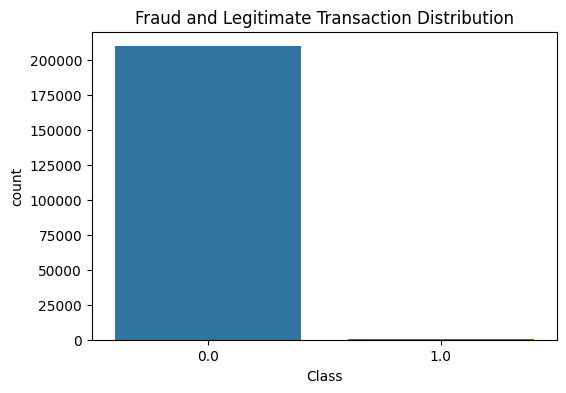

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class",data=credit_card_fraud_dataset)
plt.title("Fraud and Legitimate Transaction Distribution")
plt.show()

# **Fraud Percentage**

In [51]:
credit_card_fraud_dataset["Class"].value_counts(normalize=True)*100

,proportion
Class,
0.0,99.812392
1.0,0.187608


# Remove Transaction ID

In [52]:
credit_card_fraud_dataset=credit_card_fraud_dataset.drop("Time",axis=1)

# **Check Final Dataset**

In [53]:
credit_card_fraud_dataset.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [54]:
credit_card_fraud_dataset.shape

(210012, 30)

# Dataset Class Distribution

In [55]:
# Class = 0 (Legitimate)
# Class = 1 (Fraud)

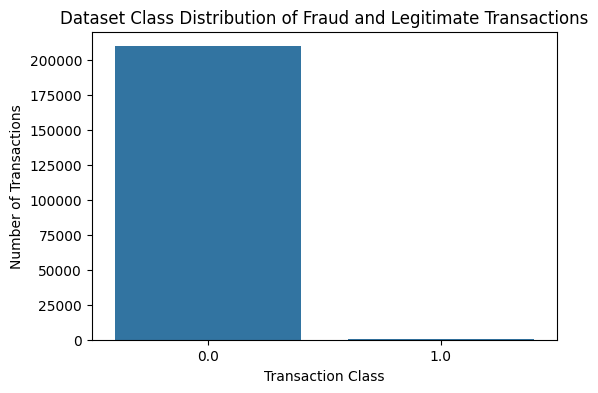

In [56]:
# Dataset Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=credit_card_fraud_dataset
)

plt.title("Dataset Class Distribution of Fraud and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

# Transaction Amount Distribution

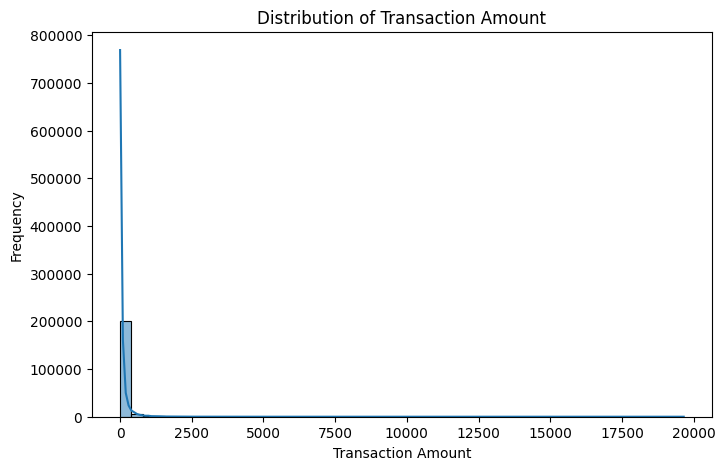

In [57]:
# Transaction Amount Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    credit_card_fraud_dataset["Amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

# Fraud Transaction Amount Comparison

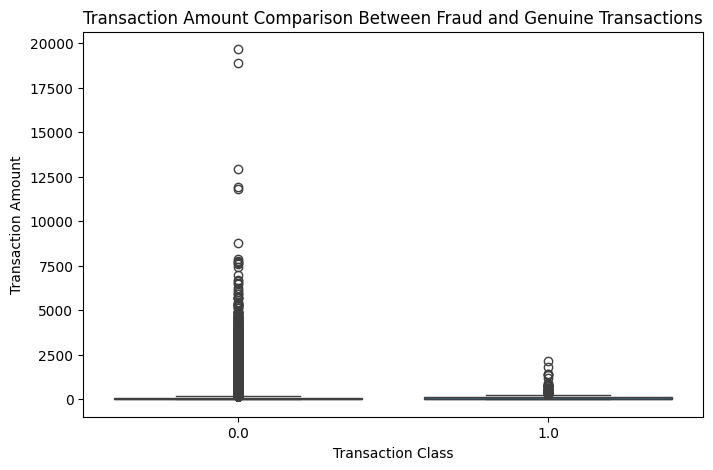

In [58]:
# Fraud vs Genuine Transaction Amount Comparison

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=credit_card_fraud_dataset
)

plt.title("Transaction Amount Comparison Between Fraud and Genuine Transactions")

plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.show()

# Feature Correlation Heatmap

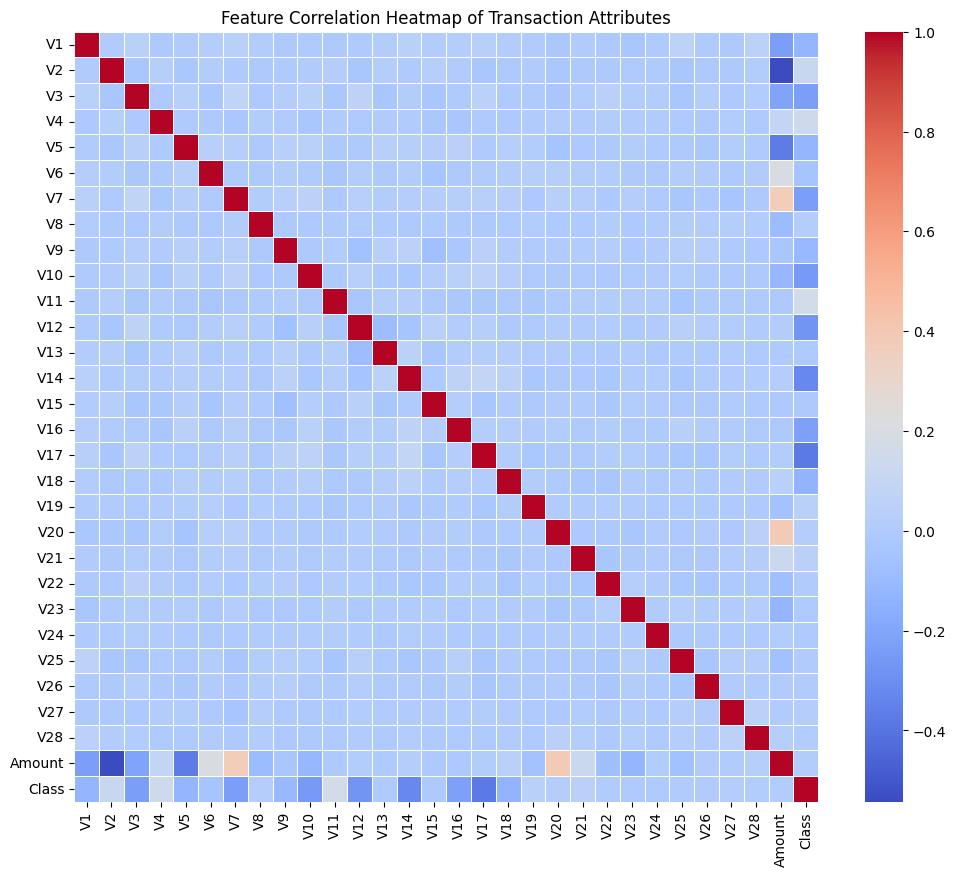

In [59]:
# Feature Correlation Heatmap

plt.figure(figsize=(12,10))

correlation_matrix=credit_card_fraud_dataset.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap of Transaction Attributes")

plt.show()

# Fraud vs Genuine Transaction Patterns

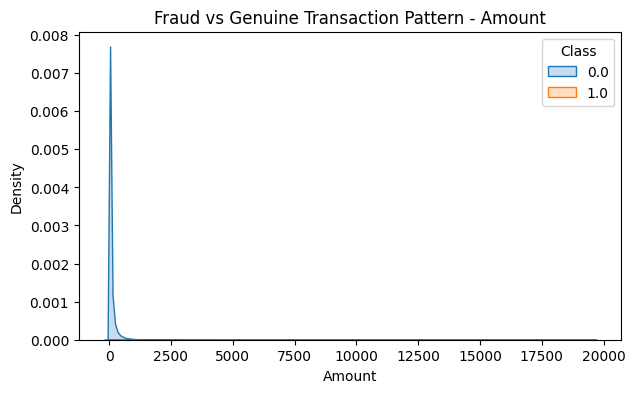

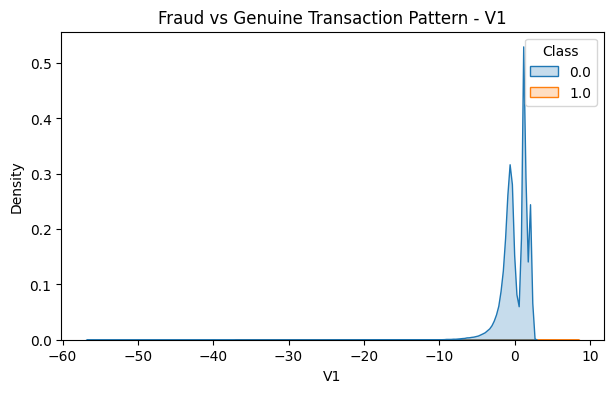

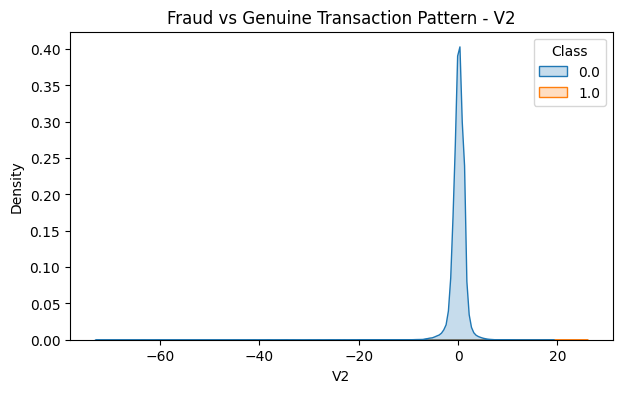

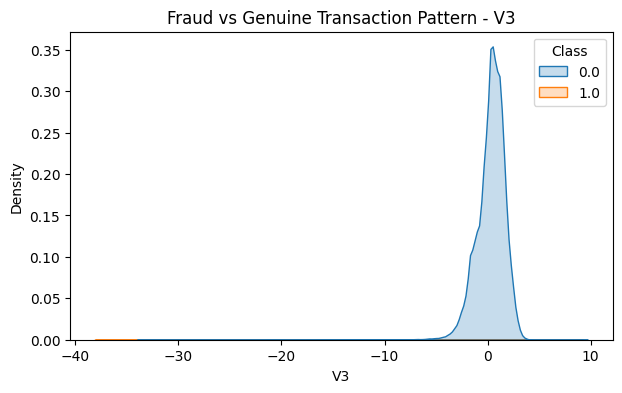

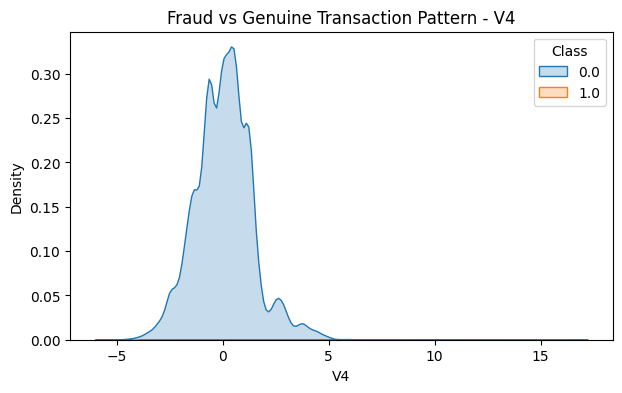

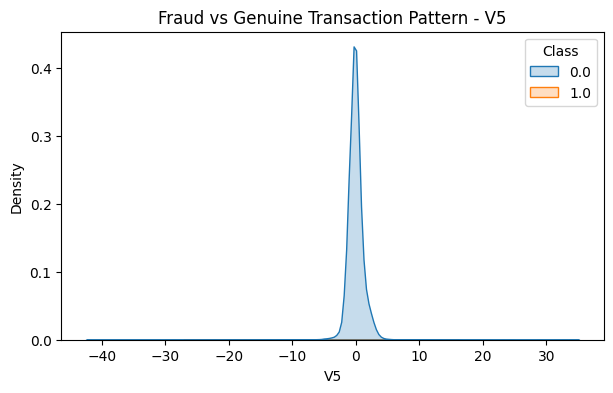

In [60]:
# Fraud vs Genuine Transaction Patterns

features=["Amount","V1","V2","V3","V4","V5"]

fraud_pattern_data=credit_card_fraud_dataset[features+["Class"]]


for feature in features:

    plt.figure(figsize=(7,4))

    sns.kdeplot(
        data=fraud_pattern_data,
        x=feature,
        hue="Class",
        fill=True
    )

    plt.title(
        "Fraud vs Genuine Transaction Pattern - "+feature
    )

    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.show()

# Top Features Distribution by Fraud Class

In [61]:
# Mean Feature Comparison Between Fraud and Genuine Transactions

feature_difference=credit_card_fraud_dataset.groupby("Class").mean()

feature_difference.T.head(15)

Class,0.0,1.0
V1,-0.075414,-5.564086
V2,-0.010262,4.145138
V3,0.280457,-7.653811
V4,0.054282,4.735781
V5,-0.083780,-4.009483
V6,0.043500,-1.393320
V7,-0.027880,-6.501846
V8,0.010674,0.664570
V9,0.012168,-2.742972
V10,0.004263,-6.297907


<Figure size 1000x500 with 0 Axes>

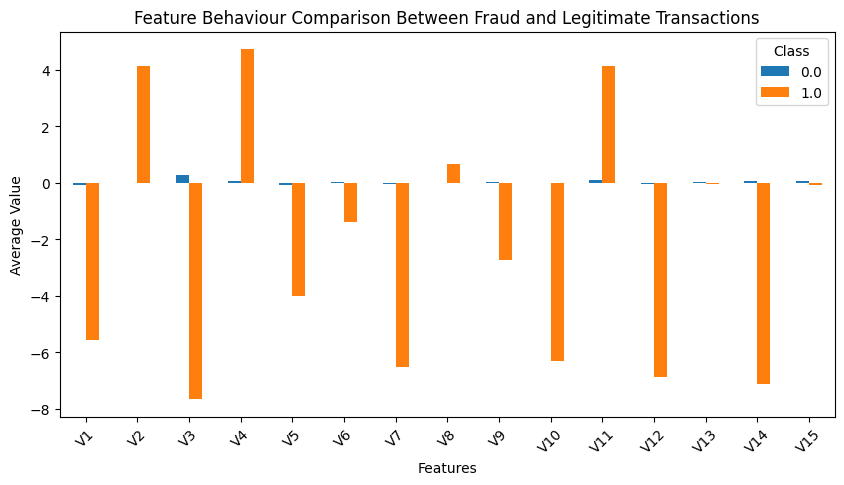

In [62]:
plt.figure(figsize=(10,5))

feature_difference.T.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Behaviour Comparison Between Fraud and Legitimate Transactions")

plt.xlabel("Features")

plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.show()

# Separate Features and Target

In [63]:
X=credit_card_fraud_dataset.drop("Class",axis=1)
y=credit_card_fraud_dataset["Class"]

# Feature Scaling

In [64]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [65]:
X_scaled=pd.DataFrame(X_scaled,columns=X.columns)

# Train-Test Split (80:20)

In [66]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

# Class Distribution Before SMOTE

In [67]:
y_train.value_counts()

,count
Class,
0.0,167694
1.0,315


# Apply SMOTE

In [68]:
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

# **Class Distribution After SMOTE**

In [69]:
y_train_smote.value_counts()

,count
Class,
0.0,167694
1.0,167694


In [70]:
print('Percentage of fraudulent vs legitimate transactions:')
display(credit_card_fraud_dataset['Class'].value_counts(normalize=True) * 100)

Percentage of fraudulent vs legitimate transactions:


,proportion
Class,
0.0,99.812392
1.0,0.187608


# **MACHINE LEARNING MODELS**

## Random Forest Model

In [71]:
random_forest = RandomForestClassifier(random_state=42, n_jobs=-1)
random_forest.fit(X_train_smote, y_train_smote)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

In [72]:
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

Random Forest
Accuracy: 0.9996428826512392
Precision: 0.9848484848484849
Recall: 0.8227848101265823
F1 Score: 0.896551724137931
ROC-AUC: 0.9870815061370848
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41924
         1.0       0.98      0.82      0.90        79

    accuracy                           1.00     42003
   macro avg       0.99      0.91      0.95     42003
weighted avg       1.00      1.00      1.00     42003



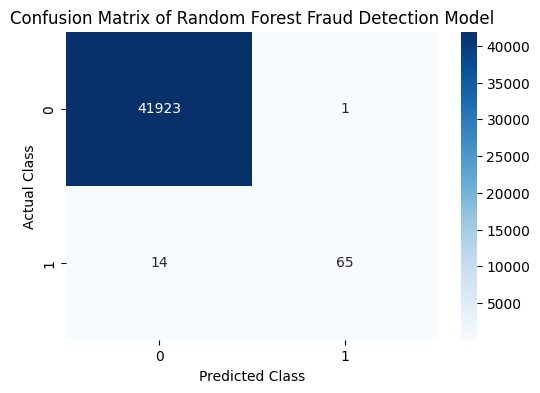

True Negative (RF): 41923
False Positive (RF): 1
False Negative (RF): 14
True Positive (RF): 65


In [73]:
rf_cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix of Random Forest Fraud Detection Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

tn_rf, fp_rf, fn_rf, tp_rf = rf_cm.ravel()
print("True Negative (RF):", tn_rf)
print("False Positive (RF):", fp_rf)
print("False Negative (RF):", fn_rf)
print("True Positive (RF):", tp_rf)

## XGBoost Model

In [74]:
xgboost_model = XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
xgboost_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgboost_model.predict(X_test)
xgb_prob = xgboost_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [16:54:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [75]:
evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

XGBoost
Accuracy: 0.9994286122419828
Precision: 0.8571428571428571
Recall: 0.8354430379746836
F1 Score: 0.8461538461538461
ROC-AUC: 0.9836008256048618
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41924
         1.0       0.86      0.84      0.85        79

    accuracy                           1.00     42003
   macro avg       0.93      0.92      0.92     42003
weighted avg       1.00      1.00      1.00     42003



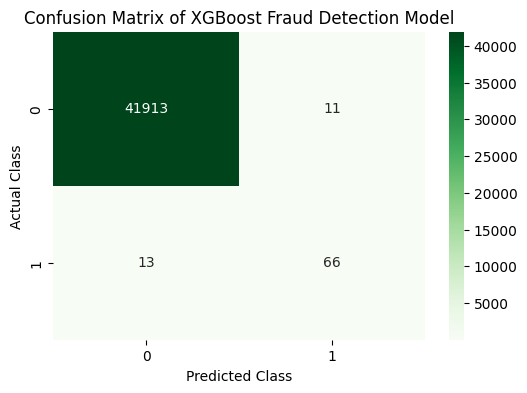

True Negative (XGBoost): 41913
False Positive (XGBoost): 11
False Negative (XGBoost): 13
True Positive (XGBoost): 66


In [76]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix of XGBoost Fraud Detection Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

tn_xgb, fp_xgb, fn_xgb, tp_xgb = xgb_cm.ravel()
print("True Negative (XGBoost):", tn_xgb)
print("False Positive (XGBoost):", fp_xgb)
print("False Negative (XGBoost):", fn_xgb)
print("True Positive (XGBoost):", tp_xgb)

# **DEEP LEARNING MODELS**

# Artificial Neural Network (ANN)

In [77]:
ann=Sequential()
ann.add(Dense(64,activation="relu",input_shape=(X_train_smote.shape[1],)))
ann.add(Dropout(0.3))
ann.add(Dense(32,activation="relu"))
ann.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
ann.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [80]:
ann_history=ann.fit(X_train_smote,y_train_smote,epochs=30,batch_size=64,validation_split=0.2)

Epoch 1/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9983 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 2/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9987 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 3/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9989 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 4/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9990 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 0.9997 - val_loss: 0.0015
Epoch 6/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 7.9237e-04
Epoch 7/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9992 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 3.9778e-04
Epoch 8/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9992 -

In [81]:
ann_prob=ann.predict(X_test)
ann_pred=(ann_prob>0.5).astype(int)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# LSTM Preparation

In [82]:
X_train_lstm=np.array(X_train_smote).reshape(X_train_smote.shape[0],1,X_train_smote.shape[1])
X_test_lstm=np.array(X_test).reshape(X_test.shape[0],1,X_test.shape[1])

# LSTM Model

In [83]:
lstm=Sequential()
lstm.add(LSTM(64,input_shape=(1,X_train_smote.shape[1])))
lstm.add(Dropout(0.3))
lstm.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [84]:
lstm.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [85]:
lstm_history=lstm.fit(X_train_lstm,y_train_smote,epochs=30,batch_size=64)

Epoch 1/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - accuracy: 0.9842 - loss: 0.0502
Epoch 2/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9978 - loss: 0.0100
Epoch 3/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9986 - loss: 0.0060
Epoch 4/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9990 - loss: 0.0042
Epoch 5/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9992 - loss: 0.0034
Epoch 6/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9994 - loss: 0.0028
Epoch 7/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9994 - loss: 0.0025
Epoch 8/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9995 - loss: 0.0022
Epoch 9/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9995 - loss: 0.0020
Epoch 10/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.9995 - loss: 0.0020
Epoch 11/30
5241/5241 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9996 - loss: 0.0015
Epoch 12/30
5241/52

In [86]:
lstm_prob=lstm.predict(X_test_lstm)
lstm_pred=(lstm_prob>0.5).astype(int)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# MODEL EVALUATION
# 26. Evaluation Function

In [87]:
def evaluate_model(name,y_test,pred,prob=None):
    print(name)
    print("Accuracy:",accuracy_score(y_test,pred))
    print("Precision:",precision_score(y_test,pred))
    print("Recall:",recall_score(y_test,pred))
    print("F1 Score:",f1_score(y_test,pred))
    if prob is not None:
        print("ROC-AUC:",roc_auc_score(y_test,prob))
    print(classification_report(y_test,pred))

# Compare All Models

In [88]:
evaluate_model("ANN",y_test,ann_pred,ann_prob)

ANN
Accuracy: 0.9992143418327263
Precision: 0.7613636363636364
Recall: 0.8481012658227848
F1 Score: 0.8023952095808383
ROC-AUC: 0.9762981295871129
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41924
         1.0       0.76      0.85      0.80        79

    accuracy                           1.00     42003
   macro avg       0.88      0.92      0.90     42003
weighted avg       1.00      1.00      1.00     42003



In [89]:
evaluate_model("LSTM",y_test,lstm_pred,lstm_prob)

LSTM
Accuracy: 0.9994286122419828
Precision: 0.8666666666666667
Recall: 0.8227848101265823
F1 Score: 0.8441558441558441
ROC-AUC: 0.9787240081207829
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     41924
         1.0       0.87      0.82      0.84        79

    accuracy                           1.00     42003
   macro avg       0.93      0.91      0.92     42003
weighted avg       1.00      1.00      1.00     42003



# Hyperparameter Optimisation for ANN

In [90]:
from tensorflow.keras.optimizers import Adam

def build_ann_model(learning_rate=0.001, dropout_rate=0.3, neurons=64):
    model=Sequential()
    model.add(Dense(neurons,activation="relu",input_shape=(X_train_smote.shape[1],)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(32,activation="relu"))
    model.add(Dense(1,activation="sigmoid"))
    model.compile(optimizer=Adam(learning_rate=learning_rate),loss="binary_crossentropy",metrics=["accuracy"])
    return model

ann_tuned=build_ann_model(learning_rate=0.0001,dropout_rate=0.2,neurons=128)

ann_tuned_history=ann_tuned.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

ann_tuned_prob=ann_tuned.predict(X_test)
ann_tuned_pred=(ann_tuned_prob>0.5).astype(int)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4193/4193 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9548 - loss: 0.1215 - val_accuracy: 0.9659 - val_loss: 0.0822
Epoch 2/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9852 - loss: 0.0414 - val_accuracy: 0.9928 - val_loss: 0.0302
Epoch 3/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9942 - loss: 0.0216 - val_accuracy: 0.9999 - val_loss: 0.0112
Epoch 4/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9968 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 5/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9978 - loss: 0.0100 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 6/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9983 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 7/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9986 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/50
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9988 - loss: 0.0053 - val

# CNN-LSTM Hybrid Deep Learning Model

In [91]:
from tensorflow.keras.layers import Conv1D,MaxPooling1D,Flatten

X_train_cnn_lstm=np.array(X_train_smote).reshape(X_train_smote.shape[0],X_train_smote.shape[1],1)
X_test_cnn_lstm=np.array(X_test).reshape(X_test.shape[0],X_test.shape[1],1)

cnn_lstm=Sequential()

cnn_lstm.add(Conv1D(filters=64,kernel_size=3,activation="relu",input_shape=(X_train_cnn_lstm.shape[1],1)))
cnn_lstm.add(MaxPooling1D(pool_size=2))
cnn_lstm.add(LSTM(64))
cnn_lstm.add(Dropout(0.3))
cnn_lstm.add(Dense(1,activation="sigmoid"))

cnn_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_history=cnn_lstm.fit(
    X_train_cnn_lstm,
    y_train_smote,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

cnn_lstm_prob=cnn_lstm.predict(X_test_cnn_lstm)
cnn_lstm_pred=(cnn_lstm_prob>0.5).astype(int)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4193/4193 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.9719 - loss: 0.0798 - val_accuracy: 0.9861 - val_loss: 0.0361
Epoch 2/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9934 - loss: 0.0196 - val_accuracy: 0.9998 - val_loss: 0.0034
Epoch 3/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9968 - loss: 0.0109 - val_accuracy: 0.9981 - val_loss: 0.0077
Epoch 4/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9989 - val_loss: 0.0034
Epoch 5/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.9984 - loss: 0.0062 - val_accuracy: 0.9987 - val_loss: 0.0050
Epoch 6/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9987 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 6.0878e-04
Epoch 7/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 8/30
4193/4193 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step - accuracy: 0.9990 - loss: 0.0038 -

# Complete Model Comparison Table

In [92]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

model_results=pd.DataFrame({
    "Model":[
        "ANN",
        "LSTM",
        "ANN Tuned",
        "CNN-LSTM"
    ],

    "Accuracy":[
        accuracy_score(y_test,ann_pred),
        accuracy_score(y_test,lstm_pred),
        accuracy_score(y_test,ann_tuned_pred),
        accuracy_score(y_test,cnn_lstm_pred)
    ],

    "Precision":[
        precision_score(y_test,ann_pred),
        precision_score(y_test,lstm_pred),
        precision_score(y_test,ann_tuned_pred),
        precision_score(y_test,cnn_lstm_pred)
    ],

    "Recall":[
        recall_score(y_test,ann_pred),
        recall_score(y_test,lstm_pred),
        recall_score(y_test,ann_tuned_pred),
        recall_score(y_test,cnn_lstm_pred)
    ],

    "F1 Score":[
        f1_score(y_test,ann_pred),
        f1_score(y_test,lstm_pred),
        f1_score(y_test,ann_tuned_pred),
        f1_score(y_test,cnn_lstm_pred)
    ]
})

model_results["Accuracy"] = (model_results["Accuracy"] * 100).round(2).astype(str) + '%'
model_results["Precision"] = (model_results["Precision"] * 100).round(2).astype(str) + '%'
model_results["Recall"] = (model_results["Recall"] * 100).round(2).astype(str) + '%'
model_results["F1 Score"] = (model_results["F1 Score"] * 100).round(2).astype(str) + '%'

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,ANN,99.92%,76.14%,84.81%,80.24%
1,LSTM,99.94%,86.67%,82.28%,84.42%
2,ANN Tuned,99.95%,87.84%,82.28%,84.97%
3,CNN-LSTM,99.94%,80.95%,86.08%,83.44%


In [93]:
all_model_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "ANN",
        "LSTM",
        "ANN Tuned",
        "CNN-LSTM"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, ann_pred),
        accuracy_score(y_test, lstm_pred),
        accuracy_score(y_test, ann_tuned_pred),
        accuracy_score(y_test, cnn_lstm_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, ann_pred),
        precision_score(y_test, lstm_pred),
        precision_score(y_test, ann_tuned_pred),
        precision_score(y_test, cnn_lstm_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, ann_pred),
        recall_score(y_test, lstm_pred),
        recall_score(y_test, ann_tuned_pred),
        recall_score(y_test, cnn_lstm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, ann_pred),
        f1_score(y_test, lstm_pred),
        f1_score(y_test, ann_tuned_pred),
        f1_score(y_test, cnn_lstm_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, ann_prob),
        roc_auc_score(y_test, lstm_prob),
        roc_auc_score(y_test, ann_tuned_prob),
        roc_auc_score(y_test, cnn_lstm_prob)
    ]
})

# Convert to percentage strings
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]:
    all_model_results[col] = (all_model_results[col] * 100).round(2).astype(str) + '%'

display(all_model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,99.96%,98.48%,82.28%,89.66%,98.71%
1,XGBoost,99.94%,85.71%,83.54%,84.62%,98.36%
2,ANN,99.92%,76.14%,84.81%,80.24%,97.63%
3,LSTM,99.94%,86.67%,82.28%,84.42%,97.87%
4,ANN Tuned,99.95%,87.84%,82.28%,84.97%,98.09%
5,CNN-LSTM,99.94%,80.95%,86.08%,83.44%,95.83%


# Extract Confusion Matrix Values

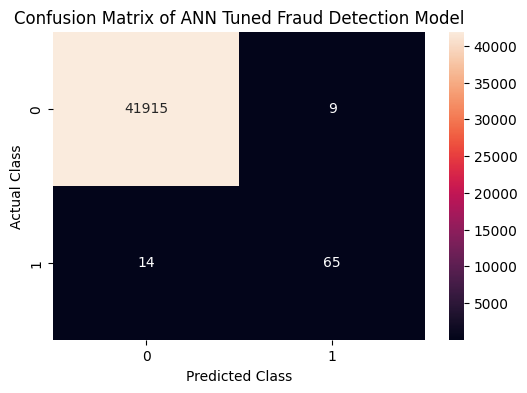

True Negative: 41915
False Positive: 9
False Negative: 14
True Positive: 65


In [94]:
ann_tuned_cm=confusion_matrix(y_test,ann_tuned_pred)
plt.figure(figsize=(6,4))
sns.heatmap(ann_tuned_cm,annot=True,fmt="d")
plt.title("Confusion Matrix of ANN Tuned Fraud Detection Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()
tn,fp,fn,tp=ann_tuned_cm.ravel()
print("True Negative:",tn)
print("False Positive:",fp)
print("False Negative:",fn)
print("True Positive:",tp)

# Calculate Fraud Detection Error Rates

In [95]:
false_positive_rate=fp/(fp+tn)
false_negative_rate=fn/(fn+tp)
print("False Positive Rate:",false_positive_rate)
print("False Negative Rate:",false_negative_rate)

False Positive Rate: 0.00021467417231180232
False Negative Rate: 0.17721518987341772


# ROC-AUC Curve Comparison (All Models)

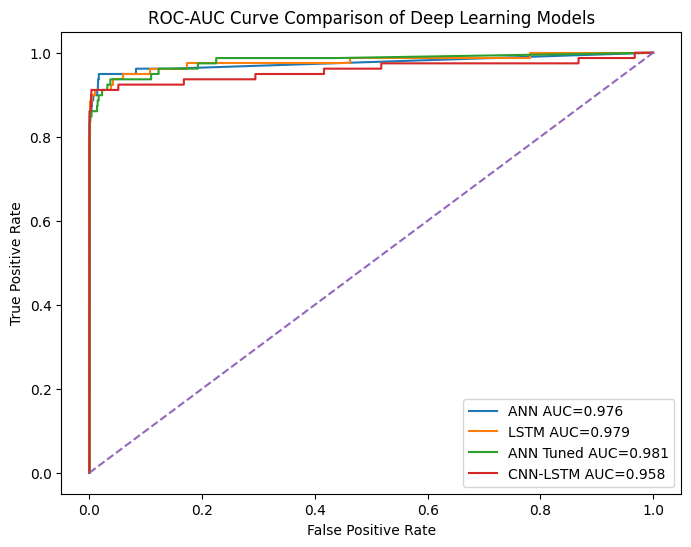

In [96]:
from sklearn.metrics import roc_curve,auc
models_probability={"ANN":ann_prob.ravel(),"LSTM":lstm_prob.ravel(),"ANN Tuned":ann_tuned_prob.ravel(),"CNN-LSTM":cnn_lstm_prob.ravel()}
plt.figure(figsize=(8,6))
for name,prob in models_probability.items():
    fpr,tpr,_=roc_curve(y_test,prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=name+" AUC="+str(round(roc_auc,3)))
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison of Deep Learning Models")
plt.legend()
plt.show()

# Feature Importance Analysis (Fraud Pattern Identification)

In [97]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

# Create a wrapper class to make Keras model compatible with sklearn's permutation_importance
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model, threshold=0.5):
        self.keras_model = keras_model
        self.threshold = threshold

    def fit(self, X, y=None):
        # Keras model is assumed to be already fitted
        return self

    def predict(self, X):
        proba = self.keras_model.predict(X, verbose=0)
        return (proba > self.threshold).astype(int)

# Create an instance of the wrapper
ann_tuned_wrapper = KerasClassifierWrapper(ann_tuned)

# Calculate permutation importance using the wrapped model
ann_tuned_importance = permutation_importance(ann_tuned_wrapper, X_test, y_test, scoring="f1", n_repeats=5, random_state=42)
ann_feature_importance = pd.DataFrame({"Feature":X.columns,"Importance":ann_tuned_importance.importances_mean})
ann_feature_importance = ann_feature_importance.sort_values(by="Importance",ascending=False)
ann_feature_importance.head(15)

,Feature,Importance
13,V14,0.428480
9,V10,0.241118
3,V4,0.177056
11,V12,0.134582
2,V3,0.112614
16,V17,0.090049
15,V16,0.075398
10,V11,0.068394
6,V7,0.062582
0,V1,0.062555


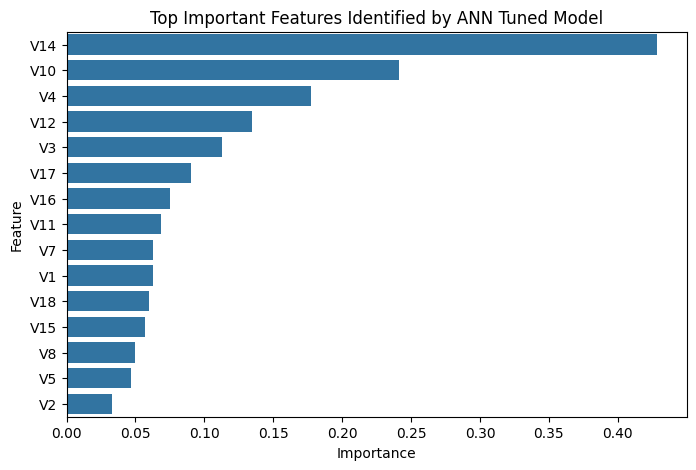

In [98]:
plt.figure(figsize=(8,5))
sns.barplot(data=ann_feature_importance.head(15),x="Importance",y="Feature")
plt.title("Top Important Features Identified by ANN Tuned Model")
plt.show()

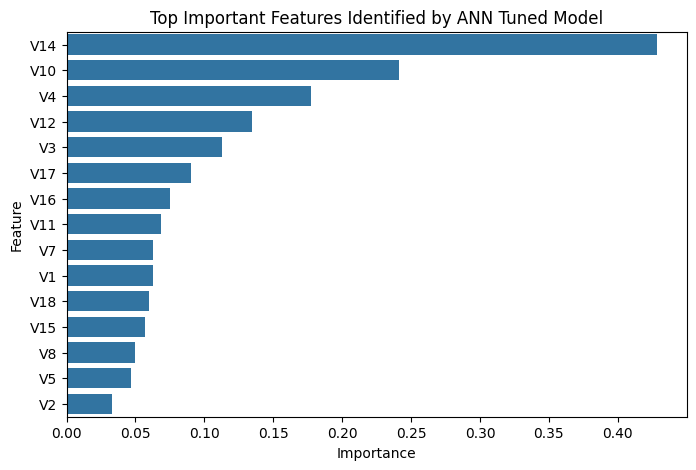

In [99]:
plt.figure(figsize=(8,5))
sns.barplot(data=ann_feature_importance.head(15),x="Importance",y="Feature")
plt.title("Top Important Features Identified by ANN Tuned Model")
plt.show()

# SHAP Explainability

In [100]:
Dense(1, activation="sigmoid")

<Dense name=dense_8, built=False>

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(100, 29))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_18
Received: inputs=['Tensor(shape=(50, 29))']
  warnings.warn(msg)


SHAP Shape: (100, 29)
Input Shape: (100, 29)


/tmp/ipykernel_2318/2819368236.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,test_sample,feature_names=X.columns)


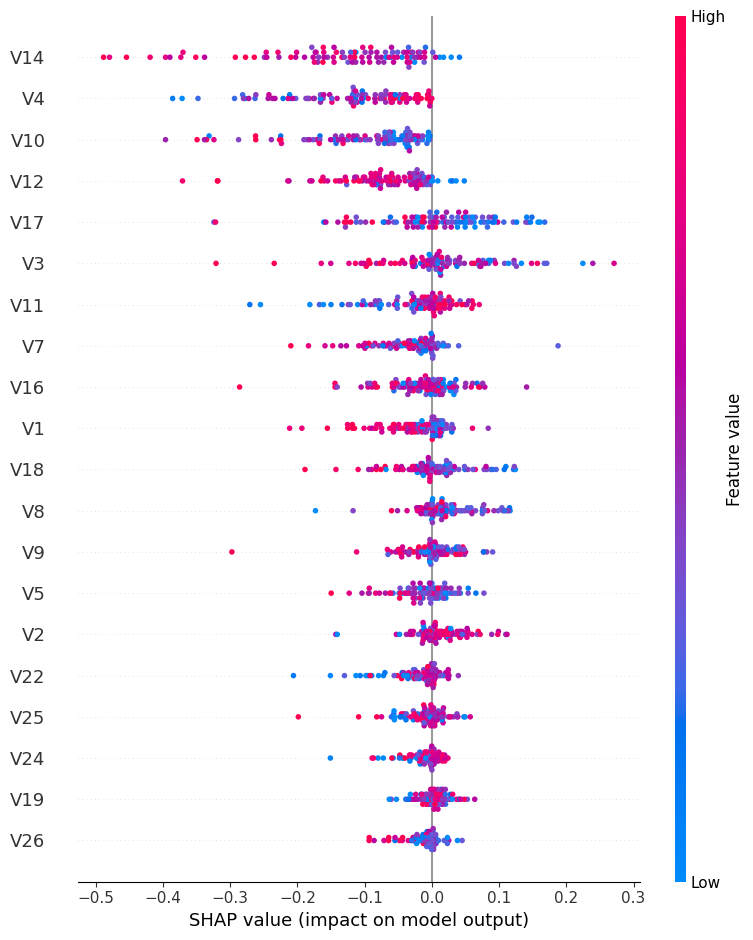

In [101]:
import shap
background=X_train_smote.sample(100,random_state=42).values
test_sample=X_test.iloc[:100].values
explainer=shap.GradientExplainer(ann_tuned,background)
shap_values=explainer.shap_values(test_sample)
if isinstance(shap_values,list):
    shap_values=shap_values[0]
shap_values=np.array(shap_values)
if len(shap_values.shape)==3:
    shap_values=shap_values[:,:,0]
print("SHAP Shape:",shap_values.shape)
print("Input Shape:",test_sample.shape)
shap.summary_plot(shap_values,test_sample,feature_names=X.columns)

## LIME (Local Interpretable Model-Agnostic Explanations)

In [102]:
# Install LIME
%pip install lime

import lime
import lime.lime_tabular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=2e6383b4d56e28699f5a91002f0fcf48c759aca40aba03edb4510b9669acb3d2
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [107]:
# Define a prediction function for LIME. It must take a 2D numpy array and return prediction probabilities.
def predict_proba_ann_tuned(data):
    proba = ann_tuned.predict(data, verbose=0)
    # For binary classification, LIME expects probabilities for both classes [P(class_0), P(class_1)]
    return np.hstack([1 - proba, proba])

In [108]:
# Define a prediction function for LIME. It must take a 2D numpy array and return prediction probabilities.
def predict_proba_ann_tuned(data):
    proba = ann_tuned.predict(data, verbose=0)
    # For binary classification, LIME expects probabilities for both classes [P(class_0), P(class_1)]
    return np.hstack([1 - proba, proba])

In [109]:
# Initialize LIME TabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_smote.values, # Use SMOTE-resampled training data as background
    feature_names=X.columns.tolist(), # Original feature names
    class_names=['Legitimate', 'Fraud'], # Class labels
    mode='classification'
)

print("LIME explainer initialized.")

LIME explainer initialized.


In [110]:
# Find an example of a fraudulent transaction from the test set
fraud_indices = np.where(y_test == 1)[0]
if len(fraud_indices) > 0:
    # Select the first fraudulent transaction
    fraud_sample_index = fraud_indices[0]
    fraud_transaction = X_test.iloc[fraud_sample_index].values

    # Generate explanation for the fraudulent transaction
    print(f"Generating LIME explanation for Fraudulent Transaction (Index in X_test: {fraud_sample_index})...")
    explanation_fraud = explainer.explain_instance(
        data_row=fraud_transaction,
        predict_fn=predict_proba_ann_tuned,
        num_features=10 # Show top 10 contributing features
    )

    # Display the explanation
    print("\nLIME Explanation for Fraudulent Transaction:")
    explanation_fraud.show_in_notebook(show_all=False)
else:
    print("No fraudulent transactions found in the test set to explain.")

Generating LIME explanation for Fraudulent Transaction (Index in X_test: 351)...

LIME Explanation for Fraudulent Transaction:


In [111]:
# Find an example of a legitimate transaction from the test set
legitimate_indices = np.where(y_test == 0)[0]
if len(legitimate_indices) > 0:
    # Select the first legitimate transaction
    legitimate_sample_index = legitimate_indices[0]
    legitimate_transaction = X_test.iloc[legitimate_sample_index].values

    # Generate explanation for the legitimate transaction
    print(f"Generating LIME explanation for Legitimate Transaction (Index in X_test: {legitimate_sample_index})...")
    explanation_legitimate = explainer.explain_instance(
        data_row=legitimate_transaction,
        predict_fn=predict_proba_ann_tuned,
        num_features=10 # Show top 10 contributing features
    )

    # Display the explanation
    print("\nLIME Explanation for Legitimate Transaction:")
    explanation_legitimate.show_in_notebook(show_all=False)
else:
    print("No legitimate transactions found in the test set to explain.")

Generating LIME explanation for Legitimate Transaction (Index in X_test: 0)...

LIME Explanation for Legitimate Transaction:


In [112]:
# Find an example of a fraudulent transaction from the test set
fraud_indices = np.where(y_test == 1)[0]
if len(fraud_indices) > 0:
    # Select the first fraudulent transaction
    fraud_sample_index = fraud_indices[0]
    fraud_transaction = X_test.iloc[fraud_sample_index].values

    # Generate explanation for the fraudulent transaction
    print(f"Generating LIME explanation for Fraudulent Transaction (Index in X_test: {fraud_sample_index})...")
    explanation_fraud = explainer.explain_instance(
        data_row=fraud_transaction,
        predict_fn=predict_proba_ann_tuned,
        num_features=10 # Show top 10 contributing features
    )

    # Display the explanation
    print("\nLIME Explanation for Fraudulent Transaction:")
    explanation_fraud.show_in_notebook(show_all=False)
else:
    print("No fraudulent transactions found in the test set to explain.")

Generating LIME explanation for Fraudulent Transaction (Index in X_test: 351)...

LIME Explanation for Fraudulent Transaction:


In [113]:
# Find an example of a legitimate transaction from the test set
legitimate_indices = np.where(y_test == 0)[0]
if len(legitimate_indices) > 0:
    # Select the first legitimate transaction
    legitimate_sample_index = legitimate_indices[0]
    legitimate_transaction = X_test.iloc[legitimate_sample_index].values

    # Generate explanation for the legitimate transaction
    print(f"Generating LIME explanation for Legitimate Transaction (Index in X_test: {legitimate_sample_index})...")
    explanation_legitimate = explainer.explain_instance(
        data_row=legitimate_transaction,
        predict_fn=predict_proba_ann_tuned,
        num_features=10 # Show top 10 contributing features
    )

    # Display the explanation
    print("\nLIME Explanation for Legitimate Transaction:")
    explanation_legitimate.show_in_notebook(show_all=False)
else:
    print("No legitimate transactions found in the test set to explain.")

Generating LIME explanation for Legitimate Transaction (Index in X_test: 0)...

LIME Explanation for Legitimate Transaction:


### Analyze LIME Explanation for Fraudulent Transaction

In [114]:
print("Top features for Fraudulent Transaction:")
print(explanation_fraud.as_list())

Top features for Fraudulent Transaction:
[('V14 <= -6.95', 0.19405970824081648), ('V4 > 2.88', 0.1317825716284015), ('V12 <= -5.51', 0.11302599179659543), ('V8 <= -0.14', 0.08822085358416656), ('-0.81 < V10 <= -0.01', -0.08721223850049806), ('V7 <= -2.98', 0.05516905592975162), ('-6.96 < V17 <= -0.62', 0.040156548635385425), ('V1 <= -1.53', -0.039910520229581296), ('-3.51 < V3 <= -0.93', 0.0353035800891758), ('V2 > 1.74', -0.03267525650535159)]


### Analyze LIME Explanation for Legitimate Transaction

In [115]:
print("Top features for Legitimate Transaction:")
print(explanation_legitimate.as_list())

Top features for Legitimate Transaction:
[('V4 <= -0.04', -0.10149233340733742), ('-0.81 < V10 <= -0.01', -0.08427926081062696), ('-1.05 < V14 <= 0.08', -0.08400346794059449), ('V12 > 0.22', -0.0766368656922164), ('V7 > 0.21', -0.03980928695369378), ('V20 <= -0.24', 0.029127512633406166), ('-0.51 < V18 <= 0.36', 0.025529666911747524), ('V27 <= -0.13', 0.02416300583697762), ('V11 <= -0.20', -0.020085471117961856), ('-0.78 < V16 <= 0.30', -0.019687170314735748)]


### Create LIME Explainer

In [104]:
# Initialize LIME TabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_smote.values, # Use SMOTE-resampled training data as background
    feature_names=X.columns.tolist(), # Original feature names
    class_names=['Legitimate', 'Fraud'], # Class labels
    mode='classification'
)

print("LIME explainer initialized.")

LIME explainer initialized.
